In [1]:
GITHUB_USER = 'Skm48'
REPO_NAME   = 'MINI_PROJECT'

import os

if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
    print('Repo cloned!')
else:
    !cd /content/{REPO_NAME} && git pull
    print('Pulled latest changes!')

os.chdir(f'/content/{REPO_NAME}')
print(f'Working directory: {os.getcwd()}')

Cloning into 'MINI_PROJECT'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 232 (delta 11), reused 24 (delta 7), pack-reused 202 (from 1)
Receiving objects: 100% (232/232), 329.07 MiB | 16.97 MiB/s, done.
Resolving deltas: 100% (92/92), done.
Updating files: 100% (64/64), done.
Repo cloned!
Working directory: /content/MINI_PROJECT


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/Collab\ Files/Dataset.zip /content/MINI_PROJECT/data/
!unzip -q /content/MINI_PROJECT/data/Dataset.zip -d /content/MINI_PROJECT/data/

In [4]:
!rm -rf /content/MINI_PROJECT/data/chest_xray/__MACOSX
!rm -rf /content/MINI_PROJECT/data/chest_xray/chest_xray
!ls /content/MINI_PROJECT/data/chest_xray/

test  train  val


In [5]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from src.dataset import get_dataloaders
from src.utils import load_config, set_seed, get_device

set_seed(42)
device = get_device()
config = load_config()

print(f'Device: {device}')



Using CPU
Device: cpu


In [6]:
loaders = get_dataloaders(config)
print('Dataloaders ready')

Total images found: 5856
  By original split: {'train': np.int64(5216), 'test': np.int64(624), 'val': np.int64(16)}
  By label: {1: np.int64(4273), 0: np.int64(1583)}

Merged train+val: 5232 images
Original test kept: 624 images

New split sizes:
  Train: 4650  (Normal: 1199, Pneumonia: 3451)
  Val:   582  (Normal: 150, Pneumonia: 432)
  Test:  624  (Normal: 234, Pneumonia: 390)

Split indices saved to: data/split_indices.csv

Class weights: Normal=1.939, Pneumonia=0.674

DataLoaders ready:
  Train: 146 batches (4650 images)
  Val:   19 batches (582 images)
  Test:  20 batches (624 images)
Dataloaders ready


In [7]:
# ── VGG16 ────────────────────────────────────────────────
vgg16 = models.vgg16(weights='IMAGENET1K_V1')
vgg16.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
vgg16.load_state_dict(
    torch.load('model/checkpoints/vgg16_best.pth', map_location=device)
)
vgg16 = vgg16.to(device)
vgg16.eval()
print('VGG16 loaded')

# ── ResNet50 ─────────────────────────────────────────────
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
resnet50.load_state_dict(
    torch.load('model/checkpoints/resnet50_best.pth', map_location=device)
)
resnet50 = resnet50.to(device)
resnet50.eval()
print('ResNet50 loaded')

# ── EfficientNet-B0 ──────────────────────────────────────
efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
efficientnet.classifier = nn.Sequential(
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
efficientnet.load_state_dict(
    torch.load('model/checkpoints/efficientnet_b0_best.pth', map_location=device)
)
efficientnet = efficientnet.to(device)
efficientnet.eval()
print('EfficientNet-B0 loaded')

print('\nAll three models ready!')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 67.6MB/s]


VGG16 loaded
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


ResNet50 loaded
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s] 


EfficientNet-B0 loaded

All three models ready!


In [8]:
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in loaders['test']:
        images = images.to(device)

        p1 = torch.softmax(vgg16(images),        dim=1)
        p2 = torch.softmax(resnet50(images),     dim=1)
        p3 = torch.softmax(efficientnet(images), dim=1)

        fused = (p1 + p2 + p3) / 3.0

        preds = fused.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(fused[:, 1].cpu().numpy())

print(f'Done. Total test samples: {len(all_labels)}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Done. Total test samples: 624


In [9]:
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

accuracy = sum(1 for a, b in zip(all_labels, all_preds) if a == b) / len(all_labels)
f1  = f1_score(all_labels, all_preds, average='weighted')
auc = roc_auc_score(all_labels, all_probs)

print(f'Accuracy:  {accuracy:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.61      0.75       234
   Pneumonia       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624

Accuracy:  0.8510
F1 Score:  0.8411
AUC-ROC:   0.9646


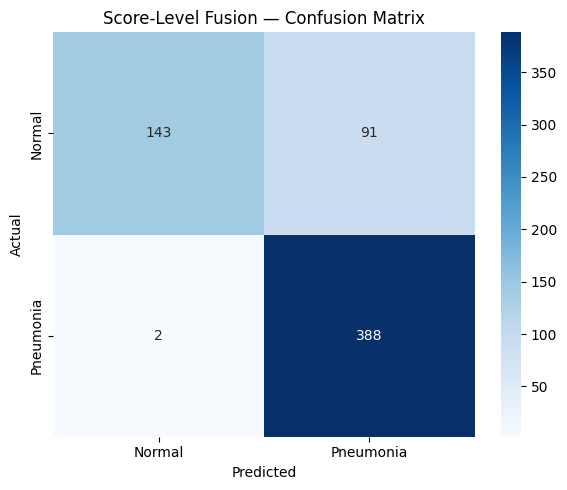

True Negatives  (Normal correct):      143
False Positives (Normal → Pneumonia):  91
False Negatives (Pneumonia → Normal):  2
True Positives  (Pneumonia correct):   388


In [10]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Score-Level Fusion — Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/figures/fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Normal correct):      {tn}')
print(f'False Positives (Normal → Pneumonia):  {fp}')
print(f'False Negatives (Pneumonia → Normal):  {fn}')
print(f'True Positives  (Pneumonia correct):   {tp}')

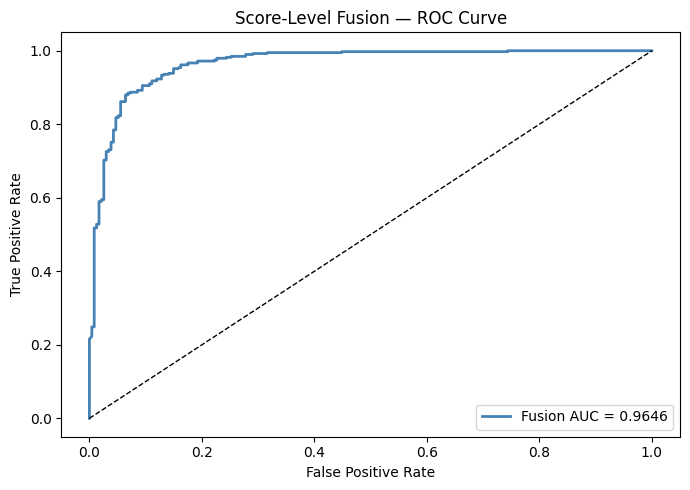

In [11]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Fusion AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Score-Level Fusion — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/figures/fusion_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

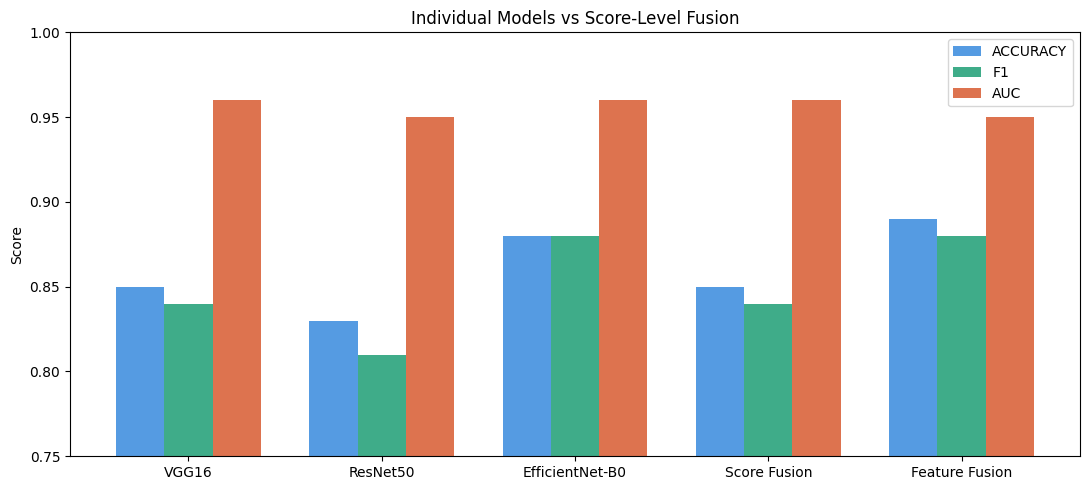

In [12]:
# ── Update these with your actual individual model results ──
results = {
    'VGG16':          {'accuracy': 0.85, 'f1': 0.84, 'auc': 0.96},
    'ResNet50':       {'accuracy': 0.83, 'f1': 0.81, 'auc': 0.95},
    'EfficientNet-B0':{'accuracy': 0.88, 'f1': 0.88, 'auc': 0.96},
    'Score Fusion':   {'accuracy': round(accuracy, 2),
                       'f1':       round(f1, 2),
                       'auc':      round(auc, 2)},
    'Feature Fusion':{'accuracy': 0.89, 'f1': 0.88, 'auc': 0.95},

}

models_list = list(results.keys())
metrics     = ['accuracy', 'f1', 'auc']
colors      = ['#378ADD', '#1D9E75', '#D85A30']

x     = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in models_list]
    ax.bar(x + i * width, vals, width, label=metric.upper(), color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(models_list)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.set_title('Individual Models vs Fusion')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/fusion_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
!cd /content/MINI_PROJECT && git config user.name "Skm48"
!cd /content/MINI_PROJECT && git config user.email "skm48@student.le.ac.uk"


In [14]:
!cd /content/MINI_PROJECT && git remote set-url origin https://Skm48@github.com/Skm48/MINI_PROJECT.git


In [15]:

!cp /content/drive/My\ Drive/Colab\ Notebooks/05b_Model_Score_Fusion.ipynb /content/MINI_PROJECT/notebooks/

cp: cannot stat '/content/drive/My Drive/Colab Notebooks/05b_Model_Score_Fusion.ipynb': No such file or directory
